# MiniTaller — Entrenar tu primer modelo propio

Vamos a entrenar nuestro propio modelo usando un dataset de promedios de estudiantes de la Unisimón.
El dataset es sintético (generado) y lo usaremos para:

- **Modelo A — Regresión:** predecir la nota de un estudiante (un número entre 1.0 y 5.0)
- **Modelo B — Clasificación:** predecir si un estudiante aprueba o reprueba (nota ≥ 3.0)

Usaremos el paquete **scikit-learn**, el más popular para Machine Learning en Python.

## 1. Instalaciones Requeridas

In [41]:
!pip install pandas scikit-learn matplotlib seaborn

## 2. Obtención del Dataset

En lugar de subir un archivo manualmente a Colab (que se borra cada vez que se cierra), lo cargamos directamente desde una URL pública en internet.

El dataset está alojado en GitHub y lo leemos con `pandas` usando `read_csv(url)`.

In [42]:
import pandas as pd

URL = "https://stivenson.github.io/datasets/promedios_estudiantes_unisimon.csv"

df = pd.read_csv(URL)

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

Dataset cargado correctamente.
Filas: 1000 | Columnas: 6


,codigo,nombre,carrera,semestre,materia,nota
0,CS20230001,Iván Sánchez Martínez,Comunicación Social,5,Producción Audiovisual,3.04
1,OD20220002,Mauricio Núñez Rodríguez,Odontología,7,Anatomía Dental,3.09
2,AE20250003,Rafael Martínez Aguilar,Administración de Empresas,9,Finanzas,3.64
3,CS20240004,Alejandro Bermúdez Flores,Comunicación Social,7,Publicidad,3.38
4,PS20240005,Luisa Pérez Rodríguez,Psicología,2,Social,4.40


## 3. Exploración Básica

Antes de entrenar cualquier modelo, siempre exploramos los datos para entender qué tenemos.

In [43]:
# Tipos de datos de cada columna
df.dtypes

,0
codigo,object
nombre,object
carrera,object
semestre,int64
materia,object
nota,float64


In [44]:
# Estadísticas básicas de las columnas numéricas
df.describe()

,semestre,nota
count,1000.000000,1000.000000
mean,5.618000,3.805260
std,2.927909,0.724579
min,1.000000,1.040000
25%,3.000000,3.530000
50%,6.000000,3.880000
75%,8.000000,4.320000
max,10.000000,5.000000


In [45]:
# ¿Cuántos estudiantes hay por carrera?
df['carrera'].value_counts()

,count
carrera,
Comunicación Social,83
Ingeniería Industrial,73
Arquitectura,72
Odontología,70
Psicología,69
Enfermería,69
Negocios Internacionales,67
Licenciatura en Educación Infantil,67
Ingeniería de Sistemas,65


## 4. Limpieza de Datos

Dos pasos básicos que siempre hacemos antes de entrenar un modelo:
- Eliminar **filas duplicadas** (misma información repetida)
- Eliminar **valores nulos** (celdas vacías)

In [46]:
antes = len(df)
df = df.drop_duplicates()
despues = len(df)
print(f"Filas eliminadas por duplicados: {antes - despues}")

Filas eliminadas por duplicados: 0


In [47]:
print("Valores nulos por columna:")
print(df.isnull().sum())

df = df.dropna()
print(f"\nFilas finales después de limpieza: {len(df)}")

Valores nulos por columna:
codigo      0
nombre      0
carrera     0
semestre    0
materia     0
nota        0
dtype: int64

Filas finales después de limpieza: 1000


## 5. Preparación de Variables

Los modelos de scikit-learn solo entienden números. Las columnas de texto (`carrera`, `materia`) hay que convertirlas a números usando **LabelEncoder**.

In [48]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

df_modelo = df.copy()

le_carrera = LabelEncoder()
le_materia = LabelEncoder()

df_modelo['carrera_cod'] = le_carrera.fit_transform(df_modelo['carrera'])
df_modelo['materia_cod'] = le_materia.fit_transform(df_modelo['materia'])

# Features (variables de entrada) y target (lo que queremos predecir)
FEATURES = ['carrera_cod', 'semestre', 'materia_cod']

X = df_modelo[FEATURES]
y_regresion    = df_modelo['nota']
y_clasificacion = (df_modelo['nota'] >= 3.0).astype(int)  # 1 = aprueba, 0 = reprueba

# Dividimos en entrenamiento (80%) y prueba (20%)
X_train, X_test, yr_train, yr_test, yc_train, yc_test = train_test_split(
    X, y_regresion, y_clasificacion, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {len(X_train)} filas | Prueba: {len(X_test)} filas")

Entrenamiento: 800 filas | Prueba: 200 filas


## 6. Modelo A — Regresión Lineal

**Objetivo:** predecir la nota (un número continuo entre 1.0 y 5.0).

**Métrica — MAE (Mean Absolute Error):**
> "En promedio, mi predicción se equivoca en X puntos."
> Si MAE = 0.5, el modelo se equivoca medio punto en promedio. ¡Fácil de interpretar!

In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

modelo_reg = LinearRegression()
modelo_reg.fit(X_train, yr_train)

predicciones_reg = modelo_reg.predict(X_test)
mae = mean_absolute_error(yr_test, predicciones_reg)

print(f"MAE (Error Absoluto Medio): {mae:.2f} puntos")
print(f"Eso significa que el modelo se equivoca en promedio {mae:.2f} puntos en la nota.")

MAE (Error Absoluto Medio): 0.55 puntos
Eso significa que el modelo se equivoca en promedio 0.55 puntos en la nota.


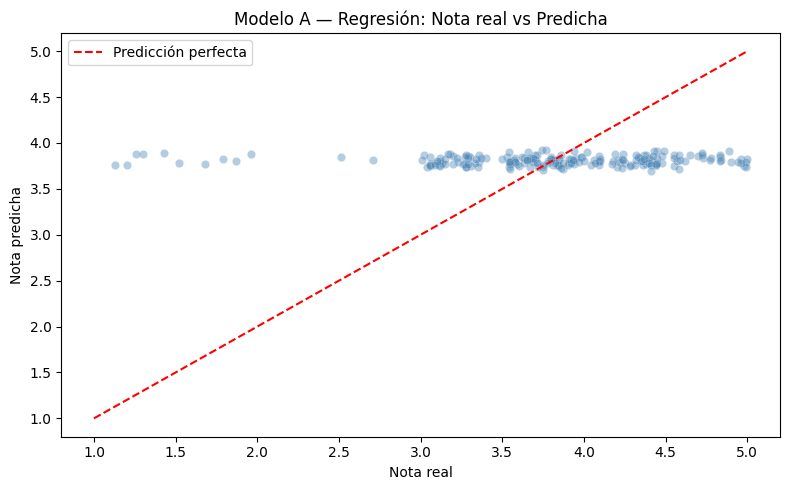

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(yr_test, predicciones_reg, alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3)
plt.plot([1, 5], [1, 5], 'r--', label='Predicción perfecta')
plt.xlabel('Nota real')
plt.ylabel('Nota predicha')
plt.title('Modelo A — Regresión: Nota real vs Predicha')
plt.legend()
plt.tight_layout()
plt.show()

# Mientras más cerca estén los puntos a la línea roja, mejor es el modelo.

## 7. Modelo B — Clasificación (¿Aprueba o Reprueba?)

**Objetivo:** predecir si un estudiante aprueba (nota ≥ 3.0) o reprueba (nota < 3.0).

Usamos un **Árbol de Decisión** — funciona como un diagrama de preguntas: "¿Es semestre > 5? ¿Es carrera X?"

**Métrica — Accuracy:**
> "De cada 100 predicciones, ¿cuántas acerté?"
> Accuracy = 0.90 → acerté el 90% de los casos.

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

modelo_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_clf.fit(X_train, yc_train)

predicciones_clf = modelo_clf.predict(X_test)
accuracy = accuracy_score(yc_test, predicciones_clf)

print(f"Accuracy: {accuracy:.2%}")
print(f"El modelo acertó el {accuracy:.2%} de las predicciones.")

Accuracy: 91.50%
El modelo acertó el 91.50% de las predicciones.


### Matriz de Confusión

La matriz de confusión nos muestra en detalle dónde acertó y dónde se equivocó el modelo:

|  | Predijo: Reprueba | Predijo: Aprueba |
|---|---|---|
| **Real: Reprueba** | ✅ Acierto | ❌ Error |
| **Real: Aprueba** | ❌ Error | ✅ Acierto |

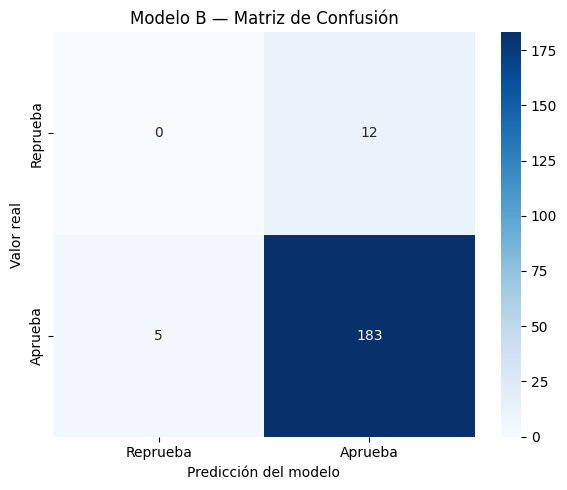

In [52]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(yc_test, predicciones_clf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Reprueba', 'Aprueba'],
    yticklabels=['Reprueba', 'Aprueba']
)
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Modelo B — Matriz de Confusión')
plt.tight_layout()
plt.show()

## 8. Importancia de Variables

El árbol de decisión nos dice qué tan importante fue cada variable para tomar sus decisiones.

> La variable con la barra más larga es la que más influyó en la predicción.

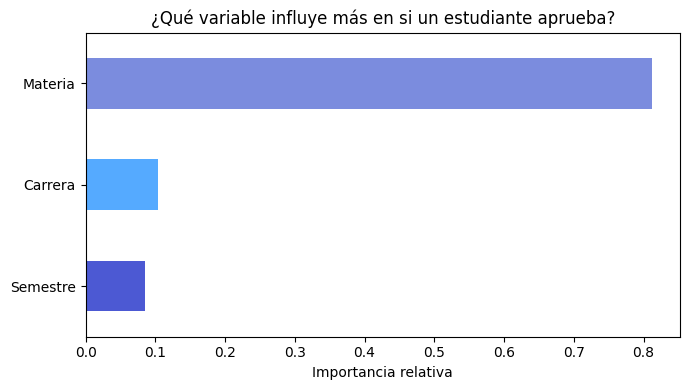

La variable más relevante para predecir si un estudiante aprueba es: Materia


In [53]:
importancias = pd.Series(
    modelo_clf.feature_importances_,
    index=['Carrera', 'Semestre', 'Materia']
).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importancias.plot(kind='barh', color=['#4C59D3', '#55AAFF', '#7B8CDE'])
plt.xlabel('Importancia relativa')
plt.title('¿Qué variable influye más en si un estudiante aprueba?')
plt.tight_layout()
plt.show()

mejor = importancias.idxmax()
print(f"La variable más relevante para predecir si un estudiante aprueba es: {mejor}")

## Resumen Final

| Modelo | Tipo | Qué predice | Métrica |
|---|---|---|---|
| Regresión Lineal | Regresión | Nota (1.0 – 5.0) | MAE |
| Árbol de Decisión | Clasificación | Aprueba / Reprueba | Accuracy |

**Conceptos aprendidos:**
- Cargar datos desde una URL remota con `pandas`
- Limpieza básica: duplicados y nulos
- Codificar variables de texto con `LabelEncoder`
- Dividir datos en entrenamiento y prueba (`train_test_split`)
- Entrenar y evaluar dos tipos de modelos con `scikit-learn`
- Visualizar resultados con `matplotlib` y `seaborn`